# Face Recognition with PCA + SVM

In this challenge we build a simple face recognition pipeline on the **Labeled Faces in the Wild (LFW)** dataset. The pipeline applies two classical techniques:

1. **PCA (Principal Component Analysis)** — also known as *Eigenfaces* in this context — to reduce the dimensionality of the images while preserving most of their variance.
2. **SVM (Support Vector Machine)** — a supervised classifier trained on the PCA-projected features to classify the faces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

## 1. Load the LFW dataset

We only keep people with at least 70 images so each class has enough training examples.

In [2]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
n_features = X.shape[1]

y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Total samples: {n_samples}")
print(f"Image shape: {h} x {w}")
print(f"Number of features (pixels): {n_features}")
print(f"Number of classes: {n_classes}")
print(f"Class names: {target_names}")

Total samples: 1288
Image shape: 50 x 37
Number of features (pixels): 1850
Number of classes: 7
Class names: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


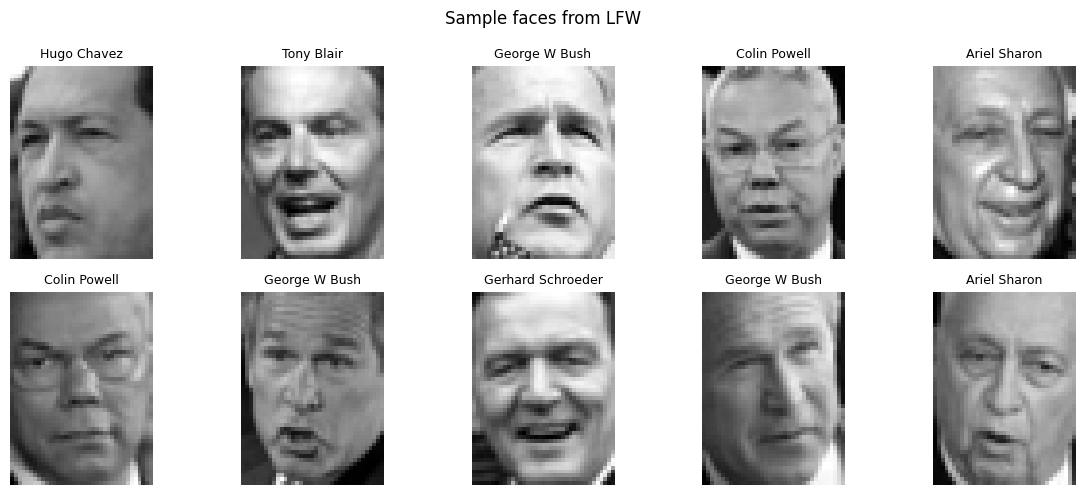

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, image, label in zip(axes.ravel(), lfw_people.images[:10], y[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(target_names[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample faces from LFW')
plt.tight_layout()
plt.show()

## 2. Train / test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Train shape: (966, 1850)
Test shape:  (322, 1850)


## 3. Apply PCA (Eigenfaces)

Each image has thousands of pixels but most of the variance is captured by a handful of **eigenfaces**. We reduce the dimensionality to 150 components. `whiten=True` scales the components so they have unit variance — this often improves SVM performance.

In [5]:
n_components = 150

pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X_train)

eigenfaces = pca.components_.reshape((n_components, h, w))

print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.4f}")

Cumulative explained variance: 0.9461


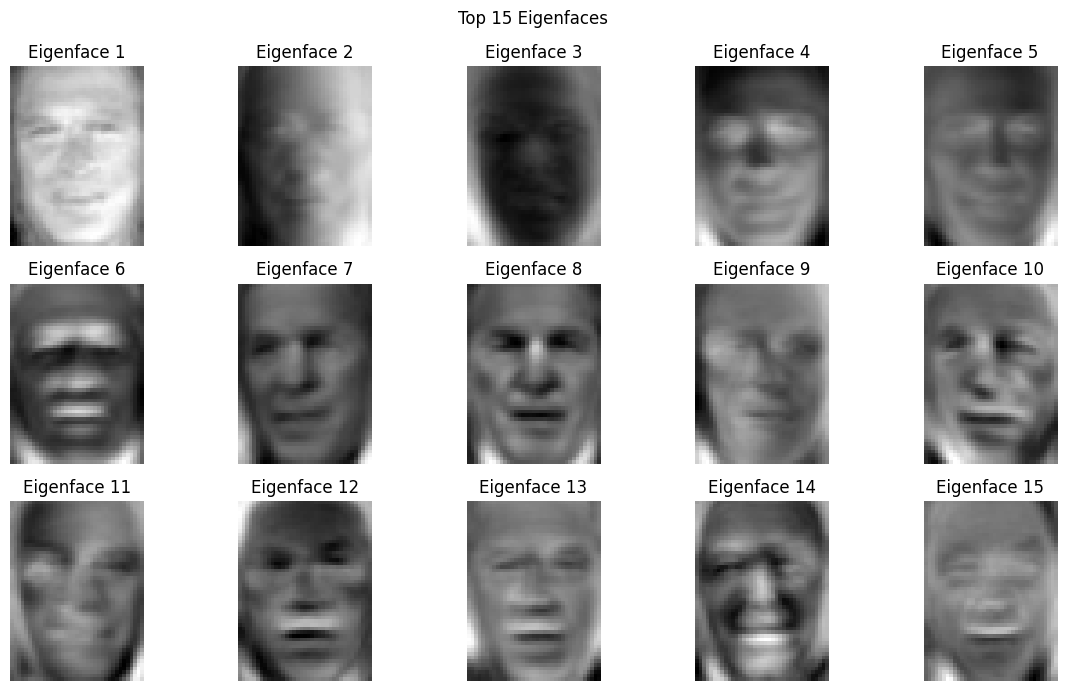

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f'Eigenface {i + 1}')
    ax.axis('off')
plt.suptitle('Top 15 Eigenfaces')
plt.tight_layout()
plt.show()

In [7]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Reduced training shape: {X_train_pca.shape}")
print(f"Reduced test shape:     {X_test_pca.shape}")

Reduced training shape: (966, 150)
Reduced test shape:     (322, 150)


## 4. Train an SVM classifier

We fit an SVM with an RBF kernel on the PCA-projected features. We use `GridSearchCV` to tune the regularization parameter `C` and the kernel coefficient `gamma`.

In [8]:
param_grid = {
    'C': [1e3, 5e3, 1e4, 5e4, 1e5],
    'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1],
}

clf = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced'),
    param_grid,
    cv=5,
    n_jobs=-1,
)
clf.fit(X_train_pca, y_train)

print(f"Best estimator: {clf.best_estimator_}")
print(f"Best CV score: {clf.best_score_:.4f}")

Best estimator: SVC(C=1000.0, class_weight='balanced', gamma=0.005)
Best CV score: 0.8126


## 5. Evaluate on the test set

In [9]:
y_pred = clf.predict(X_test_pca)

print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.93      0.68      0.79        19
     Colin Powell       0.90      0.93      0.92        59
  Donald Rumsfeld       0.87      0.67      0.75        30
    George W Bush       0.81      0.98      0.88       133
Gerhard Schroeder       0.91      0.74      0.82        27
      Hugo Chavez       1.00      0.61      0.76        18
       Tony Blair       0.97      0.81      0.88        36

         accuracy                           0.86       322
        macro avg       0.91      0.77      0.83       322
     weighted avg       0.87      0.86      0.86       322



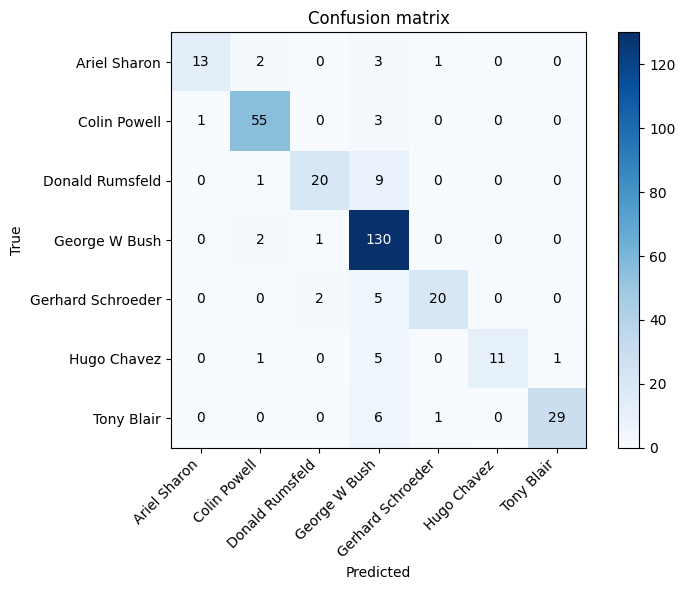

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(target_names, rotation=45, ha='right')
ax.set_yticklabels(target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix')
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 6. Visualize predictions

Display a grid of test images with their predicted and true labels.

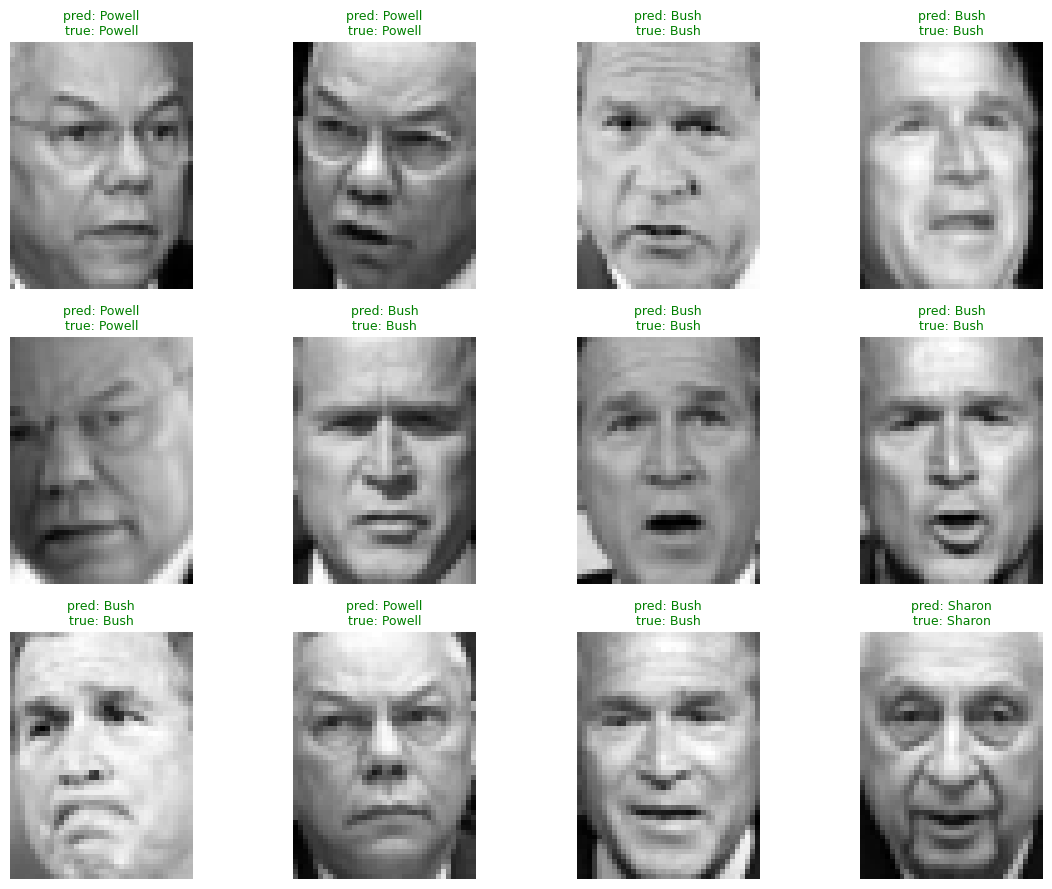

In [11]:
def title(pred, true, target_names):
    pred_name = target_names[pred].rsplit(' ', 1)[-1]
    true_name = target_names[true].rsplit(' ', 1)[-1]
    return f'pred: {pred_name}\ntrue: {true_name}'

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test[i].reshape(h, w), cmap='gray')
    t = title(y_pred[i], y_test[i], target_names)
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(t, color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. All-in-one Pipeline

As a final touch, we wrap the whole workflow (scaling, PCA, SVM) into a single `sklearn` Pipeline. This makes the code cleaner and reduces the risk of data leakage.

In [12]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=150, whiten=True, random_state=42)),
    ('svm', SVC(kernel='rbf', class_weight='balanced',
                C=clf.best_params_['C'], gamma=clf.best_params_['gamma'])),
])

pipe.fit(X_train, y_train)
test_score = pipe.score(X_test, y_test)

print(f"Pipeline test accuracy: {test_score:.4f}")

Pipeline test accuracy: 0.8571


## Conclusion

We built an end-to-end face recognition system combining:
- **PCA** to reduce thousands of pixel features into 150 eigenfaces capturing most of the variance.
- **SVM** (with an RBF kernel and hyperparameter tuning) to classify faces in the low-dimensional space.

This classical approach already reaches a strong accuracy on the LFW dataset and illustrates how unsupervised dimensionality reduction can drastically accelerate and improve downstream supervised learning.